# Exploring DESY3 redMaPPer catalogue 

## Main takeaways

## Import Statements 

In [47]:
# import daxa
# daxa.NUM_CORES = 40
# from daxa.mission import XMMPointed
# from daxa.archive import Archive
# from daxa.process.simple import full_process_xmm

# from xga.sourcetools.misc import ang_to_rad

from astropy.units import Quantity
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os

# Imports common functions/values and keeps everything consistent
from common import cosmo

## Output paths

In [50]:
samp_sel_fig_path = "../outputs/figures/sample_selection/"
os.makedirs(samp_sel_fig_path, exist_ok=True)

## Cosmology

In [2]:
cosmo

LambdaCDM(name=None, H0=<Quantity 71. km / (Mpc s)>, Om0=0.2648, Ode0=0.7352, Tcmb0=<Quantity 0. K>, Neff=3.04, m_nu=None, Ob0=0.0448)

## Loading data files

Important considerations for this dataset:

* Though a version of the DESY3 redMaPPer catalogue is publicly available [(DES Collaboration et al. 2025)](https://ui.adsabs.harvard.edu/abs/2025arXiv250313632D), it does not contain $\lambda_{\rm{RM}} < 20$ entries, so the candidate-selection part of our analysis is unfortunately not easily repeatable.
* 'LAMBDA_CHISQ'
* 'Z_LAMBDA'

### DESY3 redMaPPer v6.4.22+2

* Photometric catalogue v2.2.1-GOLD

In [38]:
with fits.open("../sample_files/noupload_desy3_gold_2.2.1_wide_sofcol_run2_redmapper_v6.4.22+2_lgt5_vl50_catalog.fits") as reado:
    rm_fits = Table(reado[1].data)
    nonvector_col_names = [name for name in rm_fits.colnames if len(rm_fits[name].shape) <= 1]
    desy3rm_samp = rm_fits[nonvector_col_names].to_pandas()

# Adding a name column with our standard naming scheme for RM clusters
desy3rm_samp.insert(1, 'name', desy3rm_samp['MEM_MATCH_ID'].apply(lambda x: 'DESY3RM-'+str(x)))
desy3rm_samp.head(6)

,MEM_MATCH_ID,name,RA,DEC,REFMAG,REFMAG_ERR,ZRED,ZRED_E,ZRED_CHISQ,BCG_SPEC_Z,...,Q_MISS,BCG_ILUM,ILUM,Z_LAMBDA_RAW,Z_LAMBDA_E_RAW,LIM_EXPTIME,LIM_LIMMAG_DERED,LIM_LIMMAG,LIM_LIMMAG_HARD,MASKGAL_INDEX
0,1,DESY3RM-1,43.564579,-58.952959,17.211803,0.003261,0.419903,0.019822,2.070493,-1.0,...,-5.499822,6.752811,154.952332,0.426756,0.002930,0.280946,22.476273,22.476273,23.559084,93
1,2,DESY3RM-2,83.231902,-37.026689,15.711882,0.001031,0.253236,0.010862,1.822323,-1.0,...,-16.255661,10.781266,160.152939,0.283757,0.002188,0.227620,22.317131,22.317131,23.559084,64
2,3,DESY3RM-3,347.092550,-2.192137,15.605037,0.001559,0.262504,0.011155,3.970640,-1.0,...,-26.678312,12.810082,133.820053,0.293272,0.002259,0.166704,22.081652,22.081652,23.559084,35
3,4,DESY3RM-4,79.155685,-54.500459,15.721151,0.001261,0.277025,0.011471,2.461007,-1.0,...,-15.530748,12.091534,146.935974,0.299716,0.001979,0.267186,22.438305,22.438305,23.559084,45
4,5,DESY3RM-5,343.585508,-46.346819,16.176292,0.001296,0.263685,0.011762,1.282380,-1.0,...,-13.001194,6.285003,118.404129,0.269913,0.002302,0.172497,22.107477,22.107477,23.559084,96
5,6,DESY3RM-6,62.795693,-48.327679,16.902008,0.002100,0.376988,0.018900,1.314089,-1.0,...,-11.425548,8.388095,122.754044,0.413390,0.003325,0.318933,22.572155,22.572155,23.559084,6


In [40]:
print("There are {n} entries in the full DESY3RM sample".format(n=len(desy3rm_samp)))

There are 869335 entries in the full DESY3RM sample


## Selecting a sample of redMaPPer candidates for further analysis

### DESY3RM$_{\lambda\leq20}$

In [9]:
desy3rm_lowR_samp = desy3rm_samp[desy3rm_samp['LAMBDA_CHISQ'] <= 20].reset_index(drop=True)
desy3rm_lowR_samp.head(6)

,MEM_MATCH_ID,name,RA,DEC,REFMAG,REFMAG_ERR,ZRED,ZRED_E,ZRED_CHISQ,BCG_SPEC_Z,...,Q_MISS,BCG_ILUM,ILUM,Z_LAMBDA_RAW,Z_LAMBDA_E_RAW,LIM_EXPTIME,LIM_LIMMAG_DERED,LIM_LIMMAG,LIM_LIMMAG_HARD,MASKGAL_INDEX
0,13,DESY3RM-13,342.179403,-44.528011,19.552191,0.020031,0.298372,0.017039,9.154387,-1.0,...,0.312723,0.491065,2.519670,0.345199,0.004135,0.234911,22.340971,22.340971,23.559084,86
1,22,DESY3RM-22,79.037258,-54.468903,18.824158,0.005987,0.335606,0.013674,7.190090,-1.0,...,0.310858,0.740317,4.067245,0.308671,0.003812,0.342603,22.626282,22.626282,23.559084,26
2,27,DESY3RM-27,323.831479,1.484002,17.643797,0.004119,0.212444,0.016494,15.878660,-1.0,...,0.188510,1.092355,3.670056,0.226225,0.003440,0.253904,22.399754,22.399754,23.559084,77
3,31,DESY3RM-31,71.758207,-37.104995,19.218773,0.011336,0.548985,0.017450,9.622556,-1.0,...,0.362922,1.979242,4.392631,0.565877,0.009137,0.233550,22.336576,22.336576,23.559084,14
4,33,DESY3RM-33,56.966810,-21.700130,18.232008,0.005726,0.387665,0.017122,8.350473,-1.0,...,-0.708699,1.791175,7.608072,0.357021,0.004539,0.218364,22.285746,22.285746,23.559084,57
5,79,DESY3RM-79,69.658567,-54.297585,19.083860,0.006471,0.424219,0.025685,15.344500,-1.0,...,0.354654,1.191795,5.070216,0.424736,0.006984,0.350427,22.643353,22.643353,23.559084,99


In [37]:
print("There are {n} entries in the DESY3RM λ<=20 sample".format(n=len(desy3rm_lowR_samp)))

There are 815725 entries in the DESY3RM λ<=20 sample


#### Redshift range

In [24]:
print("Lowest redMaPPer λ<=20 redshift entry is z={z}".format(z=round(desy3rm_lowR_samp['Z_LAMBDA'].min(), 3)))
print("Lowest redMaPPer λ<=20 redshift entry is z={z}".format(z=round(desy3rm_lowR_samp['Z_LAMBDA'].max(), 3)))

Lowest redMaPPer λ<=20 redshift entry is z=0.1
Lowest redMaPPer λ<=20 redshift entry is z=0.95


Visualize the redshift range:

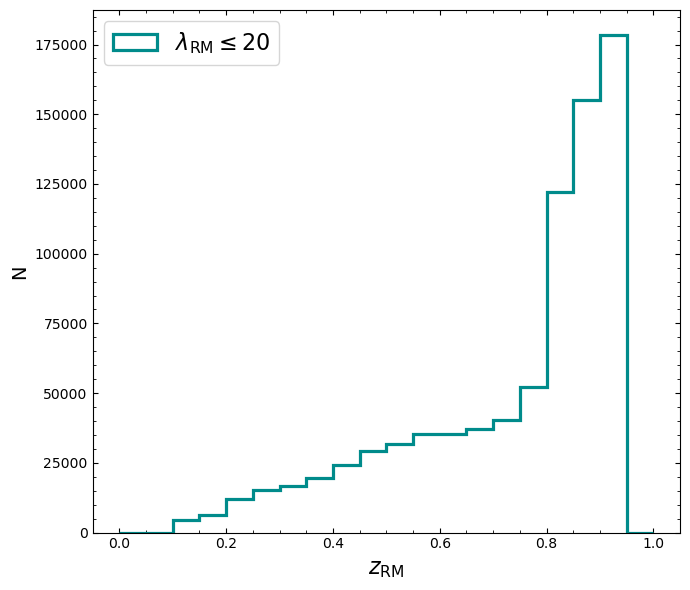

In [51]:
z_bins = np.linspace(0, 1, 21)

plt.figure(figsize=(7, 6))
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.hist(desy3rm_lowR_samp['Z_LAMBDA'].values, z_bins, histtype='step', color='darkcyan', linewidth=2.3, 
         label=r"$\lambda_{\rm{RM}}\leq20$")

plt.xlabel(r"$z_{\rm{RM}}$", fontsize=16)
plt.ylabel("N", fontsize=14)

plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig(samp_sel_fig_path + "desy3_richlte20_zdist.pdf")
plt.show()

### DESY3RM$_{\lambda\leq20,\:z\leq0.3}$

Choosing a maximum redshift value of **$z=0.3$**

In [41]:
desy3rm_lowR_lowz_samp = desy3rm_lowR_samp[desy3rm_lowR_samp['Z_LAMBDA'] <= 0.3].reset_index(drop=True)
desy3rm_lowR_lowz_samp.head(6)

,MEM_MATCH_ID,name,RA,DEC,REFMAG,REFMAG_ERR,ZRED,ZRED_E,ZRED_CHISQ,BCG_SPEC_Z,...,Q_MISS,BCG_ILUM,ILUM,Z_LAMBDA_RAW,Z_LAMBDA_E_RAW,LIM_EXPTIME,LIM_LIMMAG_DERED,LIM_LIMMAG,LIM_LIMMAG_HARD,MASKGAL_INDEX
0,27,DESY3RM-27,323.831479,1.484002,17.643797,0.004119,0.212444,0.016494,15.878660,-1.000000,...,0.188510,1.092355,3.670056,0.226225,0.003440,0.253904,22.399754,22.399754,23.559084,77
1,124,DESY3RM-124,355.920050,0.312482,17.294031,0.003609,0.290798,0.012504,6.457511,0.271846,...,-1.587308,2.362426,6.515171,0.276145,0.004436,0.275629,22.461826,22.461826,23.559084,50
2,202,DESY3RM-202,349.857931,-1.273995,18.461910,0.003051,0.278766,0.017573,25.871456,-1.000000,...,0.157317,0.903789,5.440663,0.290620,0.004827,0.321926,22.579216,22.579216,23.559084,78
3,226,DESY3RM-226,358.833265,1.805540,17.484589,0.002086,0.201648,0.023750,19.973051,-1.000000,...,0.589382,1.254885,4.511350,0.225441,0.004062,0.200066,22.219578,22.219578,23.559084,84
4,300,DESY3RM-300,61.131523,-24.284729,18.099323,0.002863,0.298846,0.017454,33.998192,-1.000000,...,0.274714,1.030668,4.069881,0.265518,0.006313,0.451127,22.834332,22.834332,23.559084,66
5,358,DESY3RM-358,69.467645,-46.070449,16.229536,0.002156,0.122096,0.011449,12.327848,-1.000000,...,0.190530,1.450287,5.066890,0.141426,0.003271,0.209639,22.254917,22.254917,23.559084,13


In [44]:
print("There are {n} entries in the DESY3RM λ<=20, z<=0.3, sample".format(n=len(desy3rm_lowR_lowz_samp)))

There are 38526 entries in the DESY3RM λ<=20, z<=0.3, sample
